# AEGIS notebook

Project: AEGIS rebuild for reproducible wind anomaly, federated learning, and edge deployment evaluation.


# 04 Threshold Sensitivity

This notebook evaluates how anomaly-detection performance changes as the reconstruction-error threshold is varied.  
It uses the saved local autoencoder outputs from Notebook 03 and compares percentile-based thresholds on the same test set.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

ROOT = Path.cwd()
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
TABLES_DIR = ROOT / "tables"

for d in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="paper")
mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "font.family": "DejaVu Serif"
})

NOTEBOOK_NAME = "04_threshold_sensitivity.ipynb"

In [2]:
train_err_path = RESULTS_DIR / "03_train_normal_reconstruction_errors.csv"
test_err_path = RESULTS_DIR / "03_test_reconstruction_errors.csv"

train_df = pd.read_csv(train_err_path)
test_df = pd.read_csv(test_err_path)

print("Train error columns:", list(train_df.columns))
print("Test error columns:", list(test_df.columns))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train error columns: ['train_error']
Test error columns: ['test_error', 'true_label', 'pred_label']
Train rows: 87620
Test rows: 43384


In [5]:
import numpy as np
import pandas as pd

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of these columns found: {candidates}. Available columns: {df.columns.tolist()}")

train_error_col = find_col(train_df, [
    "train_error", "reconstruction_error", "error", "mse", "train_reconstruction_error"
])

test_error_col = find_col(test_df, [
    "test_error", "reconstruction_error", "error", "mse", "test_reconstruction_error"
])

label_col = find_col(test_df, [
    "true_label", "label", "y_true", "actual_label"
])

pred_col = find_col(test_df, [
    "pred_label", "predicted_label", "y_pred", "prediction"
])

train_errors = train_df[train_error_col].astype(float).values
test_errors = test_df[test_error_col].astype(float).values
y_true = test_df[label_col].astype(int).values
existing_preds = test_df[pred_col].astype(int).values

print("train_error_col =", train_error_col)
print("test_error_col  =", test_error_col)
print("label_col       =", label_col)
print("pred_col        =", pred_col)

print("\nTrain errors shape:", train_errors.shape)
print("Test errors shape :", test_errors.shape)
print("True labels shape :", y_true.shape)
print("Pred labels shape :", existing_preds.shape)

train_error_col = train_error
test_error_col  = test_error
label_col       = true_label
pred_col        = pred_label

Train errors shape: (87620,)
Test errors shape : (43384,)
True labels shape : (43384,)
Pred labels shape : (43384,)


In [6]:
thresholds = [90, 92.5, 95, 97.5, 99]

rows = []
for p in thresholds:
    thr = np.percentile(train_errors, p)
    preds = (test_errors > thr).astype(int)

    tp = int(((preds == 1) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    rows.append({
        "percentile": p,
        "threshold": thr,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "predicted_anomalies": int(preds.sum())
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

,percentile,threshold,precision,recall,f1,false_positives,false_negatives,predicted_anomalies
0,90.0,0.016137,0.832122,0.522464,0.641899,2264,10257,13486
1,92.5,0.018399,0.856515,0.480516,0.615646,1729,11158,12050
2,95.0,0.021928,0.883965,0.396527,0.547471,1118,12962,9635
3,97.5,0.028773,0.900493,0.238046,0.376551,565,16366,5678
4,99.0,0.042665,0.884205,0.081056,0.148499,228,19738,1969


In [10]:
main_csv = RESULTS_DIR / "04_threshold_sensitivity.csv"
table_csv = TABLES_DIR / "04_threshold_sensitivity.csv"

threshold_df.to_csv(main_csv, index=False)
threshold_df.to_csv(table_csv, index=False)

report_df = threshold_df.copy()
report_table_csv = TABLES_DIR / "04_threshold_sensitivity_report_table.csv"
report_df.to_csv(report_table_csv, index=False)

display(report_df)

print(f"Saved: {main_csv}")
print(f"Saved: {table_csv}")
print(f"Saved: {report_table_csv}")

,percentile,threshold,precision,recall,f1,false_positives,false_negatives,predicted_anomalies
0,90.0,0.016137,0.832122,0.522464,0.641899,2264,10257,13486
1,92.5,0.018399,0.856515,0.480516,0.615646,1729,11158,12050
2,95.0,0.021928,0.883965,0.396527,0.547471,1118,12962,9635
3,97.5,0.028773,0.900493,0.238046,0.376551,565,16366,5678
4,99.0,0.042665,0.884205,0.081056,0.148499,228,19738,1969


Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\04_threshold_sensitivity.csv
Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\04_threshold_sensitivity.csv
Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\04_threshold_sensitivity_report_table.csv


In [11]:
plot_df = threshold_df.rename(columns={
    "threshold_percentile": "percentile",
    "threshold_value": "threshold",
    "fp": "false_positives",
    "fn": "false_negatives",
    "tp": "true_positives"
}).copy()

plot_df = plot_df.sort_values("percentile").reset_index(drop=True)

if "true_positives" not in plot_df.columns:
    plot_df["true_positives"] = (plot_df["predicted_anomalies"] * plot_df["precision"]).round().astype(int)

if "actual_anomalies" not in plot_df.columns:
    plot_df["actual_anomalies"] = np.where(
        plot_df["recall"] > 0,
        (plot_df["true_positives"] / plot_df["recall"]).round().astype(int),
        np.nan
    )

standard_csv_results = RESULTS_DIR / "04_threshold_sensitivity_standardized.csv"
standard_csv_tables = TABLES_DIR / "04_threshold_sensitivity_standardized.csv"

plot_df.to_csv(standard_csv_results, index=False)
plot_df.to_csv(standard_csv_tables, index=False)

display(plot_df)
print(f"Saved: {standard_csv_results}")
print(f"Saved: {standard_csv_tables}")

,percentile,threshold,precision,recall,f1,false_positives,false_negatives,predicted_anomalies,true_positives,actual_anomalies
0,90.0,0.016137,0.832122,0.522464,0.641899,2264,10257,13486,11222,21479.0
1,92.5,0.018399,0.856515,0.480516,0.615646,1729,11158,12050,10321,21479.0
2,95.0,0.021928,0.883965,0.396527,0.547471,1118,12962,9635,8517,21479.0
3,97.5,0.028773,0.900493,0.238046,0.376551,565,16366,5678,5113,21479.0
4,99.0,0.042665,0.884205,0.081056,0.148499,228,19738,1969,1741,21479.0


Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\04_threshold_sensitivity_standardized.csv
Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\04_threshold_sensitivity_standardized.csv


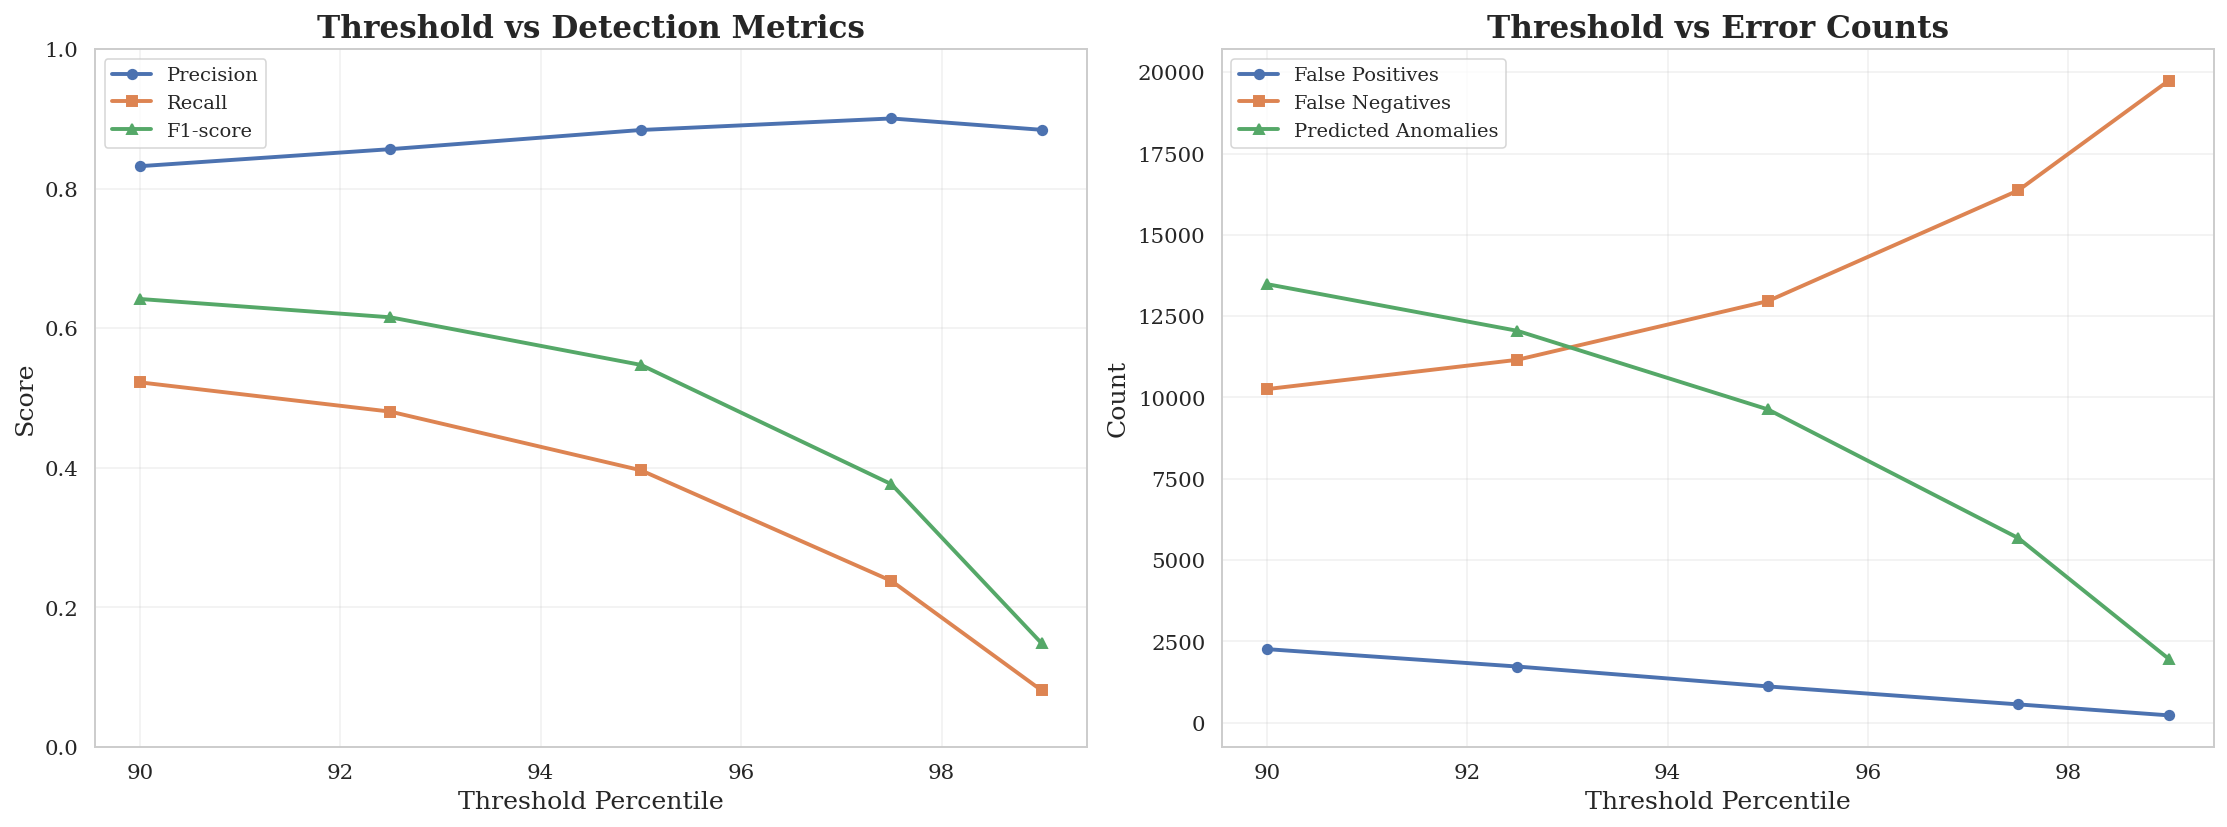

Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\figures\04_threshold_sensitivity.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(plot_df["percentile"], plot_df["precision"], marker="o", linewidth=2, label="Precision")
axes[0].plot(plot_df["percentile"], plot_df["recall"], marker="s", linewidth=2, label="Recall")
axes[0].plot(plot_df["percentile"], plot_df["f1"], marker="^", linewidth=2, label="F1-score")
axes[0].set_title("Threshold vs Detection Metrics", fontweight="bold")
axes[0].set_xlabel("Threshold Percentile")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(plot_df["percentile"], plot_df["false_positives"], marker="o", linewidth=2, label="False Positives")
axes[1].plot(plot_df["percentile"], plot_df["false_negatives"], marker="s", linewidth=2, label="False Negatives")
axes[1].plot(plot_df["percentile"], plot_df["predicted_anomalies"], marker="^", linewidth=2, label="Predicted Anomalies")
axes[1].set_title("Threshold vs Error Counts", fontweight="bold")
axes[1].set_xlabel("Threshold Percentile")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

fig_path = FIGURES_DIR / "04_threshold_sensitivity.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path}")

In [13]:
best_f1_row = plot_df.loc[plot_df["f1"].idxmax()].copy()
best_precision_row = plot_df.loc[plot_df["precision"].idxmax()].copy()
best_recall_row = plot_df.loc[plot_df["recall"].idxmax()].copy()

key_points_df = pd.DataFrame([
    {
        "selection": "Best F1",
        "percentile": best_f1_row["percentile"],
        "threshold": best_f1_row["threshold"],
        "precision": best_f1_row["precision"],
        "recall": best_f1_row["recall"],
        "f1": best_f1_row["f1"],
        "false_positives": int(best_f1_row["false_positives"]),
        "false_negatives": int(best_f1_row["false_negatives"]),
        "predicted_anomalies": int(best_f1_row["predicted_anomalies"])
    },
    {
        "selection": "Best Precision",
        "percentile": best_precision_row["percentile"],
        "threshold": best_precision_row["threshold"],
        "precision": best_precision_row["precision"],
        "recall": best_precision_row["recall"],
        "f1": best_precision_row["f1"],
        "false_positives": int(best_precision_row["false_positives"]),
        "false_negatives": int(best_precision_row["false_negatives"]),
        "predicted_anomalies": int(best_precision_row["predicted_anomalies"])
    },
    {
        "selection": "Best Recall",
        "percentile": best_recall_row["percentile"],
        "threshold": best_recall_row["threshold"],
        "precision": best_recall_row["precision"],
        "recall": best_recall_row["recall"],
        "f1": best_recall_row["f1"],
        "false_positives": int(best_recall_row["false_positives"]),
        "false_negatives": int(best_recall_row["false_negatives"]),
        "predicted_anomalies": int(best_recall_row["predicted_anomalies"])
    }
])

key_points_results = RESULTS_DIR / "04_threshold_key_points.csv"
key_points_tables = TABLES_DIR / "04_threshold_key_points.csv"

key_points_df.to_csv(key_points_results, index=False)
key_points_df.to_csv(key_points_tables, index=False)

display(key_points_df)
print(f"Saved: {key_points_results}")
print(f"Saved: {key_points_tables}")

,selection,percentile,threshold,precision,recall,f1,false_positives,false_negatives,predicted_anomalies
0,Best F1,90.0,0.016137,0.832122,0.522464,0.641899,2264,10257,13486
1,Best Precision,97.5,0.028773,0.900493,0.238046,0.376551,565,16366,5678
2,Best Recall,90.0,0.016137,0.832122,0.522464,0.641899,2264,10257,13486


Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\04_threshold_key_points.csv
Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\tables\04_threshold_key_points.csv


In [14]:
best_f1 = key_points_df[key_points_df["selection"] == "Best F1"].iloc[0]
best_precision = key_points_df[key_points_df["selection"] == "Best Precision"].iloc[0]
best_recall = key_points_df[key_points_df["selection"] == "Best Recall"].iloc[0]

summary_lines = [
    "Threshold Sensitivity Summary",
    "=============================",
    "",
    f"Best F1 operating point: {best_f1['percentile']}th percentile threshold ({best_f1['threshold']:.6f})",
    f"Precision: {best_f1['precision']:.6f}",
    f"Recall: {best_f1['recall']:.6f}",
    f"F1-score: {best_f1['f1']:.6f}",
    f"False positives: {int(best_f1['false_positives'])}",
    f"False negatives: {int(best_f1['false_negatives'])}",
    f"Predicted anomalies: {int(best_f1['predicted_anomalies'])}",
    "",
    f"Highest precision occurred at the {best_precision['percentile']}th percentile threshold ({best_precision['threshold']:.6f}).",
    f"Highest recall occurred at the {best_recall['percentile']}th percentile threshold ({best_recall['threshold']:.6f}).",
    "",
    "Interpretation:",
    "Lower thresholds increase recall but also increase false positives.",
    "Higher thresholds reduce false positives but miss more anomalies.",
    "The selected threshold should reflect whether the deployment prioritizes anomaly capture or alarm reduction."
]

summary_text = "\n".join(summary_lines)

summary_txt = RESULTS_DIR / "04_threshold_sensitivity_summary.txt"
summary_md = RESULTS_DIR / "04_threshold_sensitivity_summary.md"

with open(summary_txt, "w", encoding="utf-8") as f:
    f.write(summary_text)

with open(summary_md, "w", encoding="utf-8") as f:
    f.write("## Threshold Sensitivity Summary\n\n")
    for line in summary_lines[3:]:
        f.write(line + "\n")

print(summary_text)
print(f"\nSaved: {summary_txt}")
print(f"Saved: {summary_md}")

Threshold Sensitivity Summary

Best F1 operating point: 90.0th percentile threshold (0.016137)
Precision: 0.832122
Recall: 0.522464
F1-score: 0.641899
False positives: 2264
False negatives: 10257
Predicted anomalies: 13486

Highest precision occurred at the 97.5th percentile threshold (0.028773).
Highest recall occurred at the 90.0th percentile threshold (0.016137).

Interpretation:
Lower thresholds increase recall but also increase false positives.
Higher thresholds reduce false positives but miss more anomalies.
The selected threshold should reflect whether the deployment prioritizes anomaly capture or alarm reduction.

Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\04_threshold_sensitivity_summary.txt
Saved: C:\Users\MOINODHEEN\Moinu\Aegis_Project\results\04_threshold_sensitivity_summary.md


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

Path("tables").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

print("Imports and output folders ready.")

Imports and output folders ready.


In [4]:
baseline_result = {
    "model": "Autoencoder",
    "architecture": "81 - 64 - 32 - 16 - 32 - 64 - 81",
    "trainingsamples": 87620,
    "threshold": 0.03725784821214678,
    "precision": 0.8561542263964409,
    "recall": 0.32254760463708737,
    "f1score": 0.4685671773020865,
    "testsamples": 43384,
    "anomaliesdetected": 8092,
    "truepositives": 6928,
    "falsepositives": 1164,
    "falsenegatives": 14551
}

baseline_result

{'model': 'Autoencoder',
 'architecture': '81 - 64 - 32 - 16 - 32 - 64 - 81',
 'trainingsamples': 87620,
 'threshold': 0.03725784821214678,
 'precision': 0.8561542263964409,
 'recall': 0.32254760463708737,
 'f1score': 0.4685671773020865,
 'testsamples': 43384,
 'anomaliesdetected': 8092,
 'truepositives': 6928,
 'falsepositives': 1164,
 'falsenegatives': 14551}

In [5]:
from pathlib import Path
import os
import glob

print("Current working directory:", Path.cwd())
print("\nJSON files in root:")
print(glob.glob("*.json"))

print("\nJSON files in results/:")
print(glob.glob("results/*.json"))

print("\nCSV files in tables/:")
print(glob.glob("tables/*.csv"))

print("\nPNG/JPG files in figures/:")
print(glob.glob("figures/*"))

Current working directory: C:\Users\MOINODHEEN\Moinu\AEGIS_Project

JSON files in root:
[]

JSON files in results/:
['results\\00_run_metadata.json', 'results\\01_data_audit_summary.json', 'results\\03_artifact_summary.json', 'results\\03_local_autoencoder_metrics.json']

CSV files in tables/:
['tables\\00_path_check.csv', 'tables\\00_wind_file_inventory.csv', 'tables\\01_feature_overlap_candidates.csv', 'tables\\01_selected_feature_pairs.csv', 'tables\\01_source_summary.csv', 'tables\\01_vestas_audit.csv', 'tables\\01_vestas_columns.csv', 'tables\\01_wind_columns.csv', 'tables\\01_wind_drift_check.csv', 'tables\\01_wind_event_file_map.csv', 'tables\\01_wind_event_metadata_join.csv', 'tables\\01_wind_file_audit.csv', 'tables\\01_wind_inventory_full.csv', 'tables\\01_wind_overall_summary.csv', 'tables\\01_wind_pair_check.csv', 'tables\\01_wind_pair_compare.csv', 'tables\\02_baseline_results.csv', 'tables\\02_baseline_split_summary.csv', 'tables\\02_event_file_matches.csv', 'tables\\02_l

In [7]:
import pandas as pd
from pathlib import Path

threshold_csv_candidates = [
    Path("tables/04_threshold_sensitivity.csv"),
    Path("tables/04_threshold_sensitivity_standardized.csv"),
    Path("tables/04_threshold_sensitivity_report_table.csv")
]

threshold_path = None
for p in threshold_csv_candidates:
    if p.exists():
        threshold_path = p
        break

if threshold_path is None:
    raise FileNotFoundError("No saved threshold sensitivity CSV found in tables/")

threshold_df = pd.read_csv(threshold_path)
print("Loaded threshold table from:", threshold_path)
print(threshold_df.head())
print("\nColumns:", list(threshold_df.columns))

Loaded threshold table from: tables\04_threshold_sensitivity.csv
   percentile  threshold  precision    recall        f1  false_positives  \
0        90.0   0.016137   0.832122  0.522464  0.641899             2264   
1        92.5   0.018399   0.856515  0.480516  0.615646             1729   
2        95.0   0.021928   0.883965  0.396527  0.547471             1118   
3        97.5   0.028773   0.900493  0.238046  0.376551              565   
4        99.0   0.042665   0.884205  0.081056  0.148499              228   

   false_negatives  predicted_anomalies  
0            10257                13486  
1            11158                12050  
2            12962                 9635  
3            16366                 5678  
4            19738                 1969  

Columns: ['percentile', 'threshold', 'precision', 'recall', 'f1', 'false_positives', 'false_negatives', 'predicted_anomalies']


In [8]:
import json

with open("results/03_local_autoencoder_metrics.json", "r") as f:
    baseline_result = json.load(f)

baseline_result

{'model_name': 'deep_b32',
 'hidden_layers': '[64, 32]',
 'bottleneck': 32,
 'dropout': 0.0,
 'l2_reg': 1e-05,
 'fit_time_seconds': 55.6151,
 'epochs_run': 50,
 'parameter_count': 16817,
 'threshold': 0.021927732974572938,
 'precision': 0.8839647119875454,
 'recall': 0.3965268401694679,
 'f1': 0.5474705920164556,
 'roc_auc': 0.7232721525966892,
 'pr_auc': 0.7500663670107532,
 'tn': 20787,
 'fp': 1118,
 'fn': 12962,
 'tp': 8517,
 'predicted_anomalies': 9635,
 'train_normal_rows': 87620,
 'test_rows': 43384,
 'input_dim': 81}

In [9]:
import pandas as pd

col_map = {c.lower(): c for c in threshold_df.columns}
print(col_map)

{'percentile': 'percentile', 'threshold': 'threshold', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'false_positives': 'false_positives', 'false_negatives': 'false_negatives', 'predicted_anomalies': 'predicted_anomalies'}


In [10]:
f1_col = None
for c in threshold_df.columns:
    if c.lower() in ["f1", "f1_score", "f1score"]:
        f1_col = c
        break

if f1_col is None:
    raise ValueError("Could not find F1 column in threshold_df")

selected_threshold = threshold_df.loc[[threshold_df[f1_col].idxmax()]].copy()
selected_threshold["selection_reason"] = "Best F1 operating point from threshold sweep"
selected_threshold.to_csv("results/04_selected_threshold_summary.csv", index=False)

selected_threshold

,percentile,threshold,precision,recall,f1,false_positives,false_negatives,predicted_anomalies,selection_reason
0,90.0,0.016137,0.832122,0.522464,0.641899,2264,10257,13486,Best F1 operating point from threshold sweep


In [11]:
from pathlib import Path

for f in [
    "results/03_local_autoencoder_metrics.json",
    "tables/04_threshold_sensitivity.csv",
    "tables/04_threshold_sensitivity_standardized.csv",
    "tables/04_threshold_sensitivity_report_table.csv",
    "results/04_selected_threshold_summary.csv",
    "figures/04_threshold_sensitivity.png"
]:
    print(f, "->", Path(f).exists())

results/03_local_autoencoder_metrics.json -> True
tables/04_threshold_sensitivity.csv -> True
tables/04_threshold_sensitivity_standardized.csv -> True
tables/04_threshold_sensitivity_report_table.csv -> True
results/04_selected_threshold_summary.csv -> True
figures/04_threshold_sensitivity.png -> True
